In [340]:
!pip install catboost

In [341]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    log_loss
)

from catboost import CatBoostClassifier
import time

In [342]:


train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sample_submission = pd.read_csv("sample_submission.csv")

print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

train.head()

Train Shape: (8693, 14)
Test Shape: (4277, 13)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [343]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [344]:
train.isnull().sum()

,0
PassengerId,0
HomePlanet,201
CryoSleep,217
Cabin,199
Destination,182
Age,179
VIP,203
RoomService,181
FoodCourt,183
ShoppingMall,208


In [345]:
train.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [346]:
train["Transported"].value_counts()

,count
Transported,
True,4378
False,4315


In [347]:
train["Transported"].value_counts(normalize=True)

,proportion
Transported,
True,0.503624
False,0.496376


In [348]:
train.duplicated().sum()

np.int64(0)

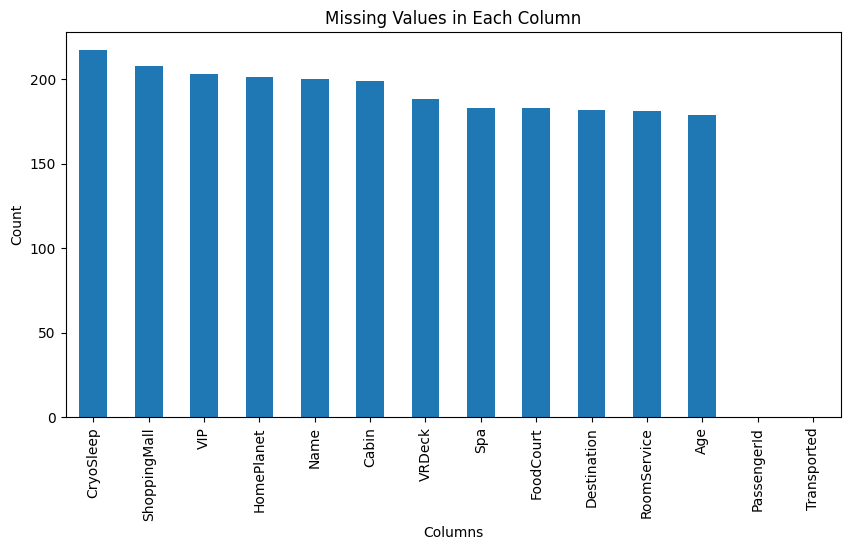

In [349]:
import matplotlib.pyplot as plt

missing = train.isnull().sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
missing.plot(kind='bar')
plt.title("Missing Values in Each Column")
plt.xlabel("Columns")
plt.ylabel("Count")
plt.show()

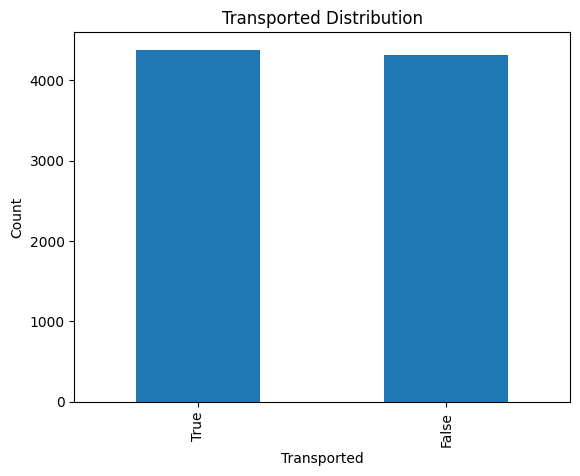

In [350]:
train["Transported"].value_counts().plot(kind="bar")

plt.title("Transported Distribution")
plt.xlabel("Transported")
plt.ylabel("Count")
plt.show()

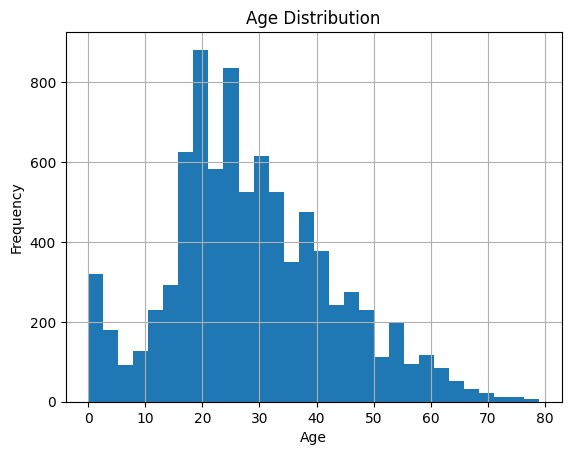

In [351]:
train["Age"].hist(bins=30)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

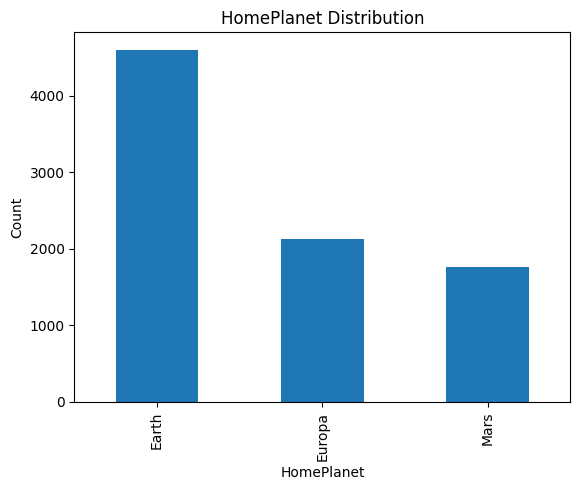

In [352]:
train["HomePlanet"].value_counts().plot(kind="bar")

plt.title("HomePlanet Distribution")
plt.xlabel("HomePlanet")
plt.ylabel("Count")
plt.show()

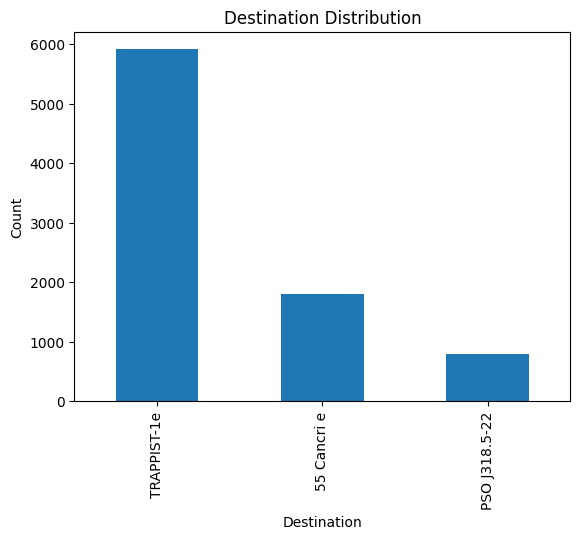

In [353]:
train["Destination"].value_counts().plot(kind="bar")

plt.title("Destination Distribution")
plt.xlabel("Destination")
plt.ylabel("Count")
plt.show()

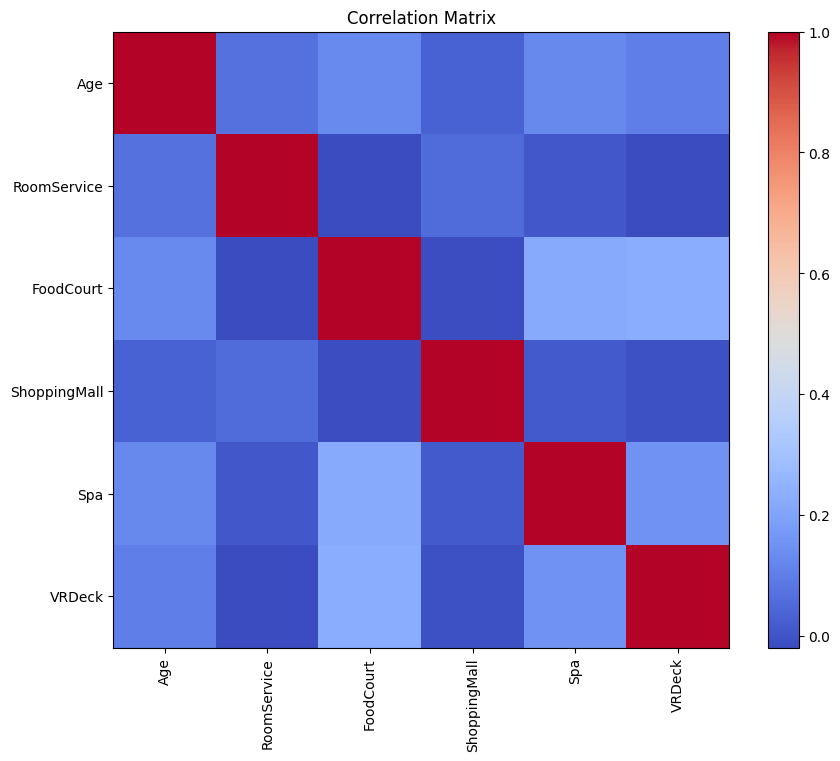

In [354]:
numeric = train.select_dtypes(include=["int64", "float64"])

corr = numeric.corr()

plt.figure(figsize=(10,8))
plt.imshow(corr, cmap="coolwarm")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")
plt.show()

In [355]:
df = train.copy()
test_df = test.copy()

In [356]:
df[['Deck', 'CabinNum', 'Side']] = df['Cabin'].str.split('/', expand=True)

test_df[['Deck', 'CabinNum', 'Side']] = test_df['Cabin'].str.split('/', expand=True)

In [357]:
df[['Cabin', 'Deck', 'CabinNum', 'Side']].head()

,Cabin,Deck,CabinNum,Side
0,B/0/P,B,0,P
1,F/0/S,F,0,S
2,A/0/S,A,0,S
3,A/0/S,A,0,S
4,F/1/S,F,1,S


In [358]:
spending_cols = [
    'RoomService',
    'FoodCourt',
    'ShoppingMall',
    'Spa',
    'VRDeck'
]

df['TotalSpending'] = df[spending_cols].fillna(0).sum(axis=1)
test_df['TotalSpending'] = test_df[spending_cols].fillna(0).sum(axis=1)

In [359]:
df[['TotalSpending']].head()

,TotalSpending
0,0.0
1,736.0
2,10383.0
3,5176.0
4,1091.0


In [360]:
df['NoSpending'] = (df['TotalSpending'] == 0).astype(int)
test_df['NoSpending'] = (test_df['TotalSpending'] == 0).astype(int)

In [361]:
df['CabinNum'] = pd.to_numeric(df['CabinNum'], errors='coerce')
test_df['CabinNum'] = pd.to_numeric(test_df['CabinNum'], errors='coerce')

In [362]:
df.drop(['PassengerId', 'Name', 'Cabin'], axis=1, inplace=True)

test_ids = test_df['PassengerId']

test_df.drop(['PassengerId', 'Name', 'Cabin'], axis=1, inplace=True)

In [363]:
df.head()

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Deck,CabinNum,Side,TotalSpending,NoSpending
0,Europa,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,False,B,0.0,P,0.0,1
1,Earth,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,True,F,0.0,S,736.0,0
2,Europa,False,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,False,A,0.0,S,10383.0,0
3,Europa,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,False,A,0.0,S,5176.0,0
4,Earth,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,True,F,1.0,S,1091.0,0


In [364]:
X = df.drop("Transported", axis=1)
y = df["Transported"]

In [365]:
print(X.shape)
print(y.shape)

(8693, 15)
(8693,)


In [366]:
categorical_cols = X.select_dtypes(include=["object"]).columns
numerical_cols = X.select_dtypes(exclude=["object"]).columns

print("Categorical Columns:")
print(categorical_cols)

print("\nNumerical Columns:")
print(numerical_cols)

Categorical Columns:
Index(['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Deck', 'Side'], dtype='object')

Numerical Columns:
Index(['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'CabinNum', 'TotalSpending', 'NoSpending'],
      dtype='object')


In [367]:

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier


In [368]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

In [369]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [370]:
print(X_train.shape)
print(X_valid.shape)

(6954, 15)
(1739, 15)


In [371]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=42
    ))
])

In [372]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'CabinNum', 'TotalSpending', 'NoSpending'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Deck', 'Side'], dtype='object'))])),
                ('classifier',
                 RandomForestClassifier(n_estimators=300, random_state=42))])

In [373]:
y_pred = model.predict(X_valid)

In [374]:
accuracy = accuracy_score(y_valid, y_pred)

print("Validation Accuracy:", accuracy)

Validation Accuracy: 0.80448533640023


In [375]:
print(classification_report(y_valid, y_pred))

              precision    recall  f1-score   support

       False       0.78      0.85      0.81       863
        True       0.83      0.76      0.80       876

    accuracy                           0.80      1739
   macro avg       0.81      0.80      0.80      1739
weighted avg       0.81      0.80      0.80      1739



In [376]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from catboost import CatBoostClassifier
from sklearn.pipeline import Pipeline

catboost_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", CatBoostClassifier(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        random_seed=42,
        verbose=0
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    catboost_pipeline,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("CV Mean Accuracy :", cv_scores.mean())
print("CV Std Accuracy  :", cv_scores.std())

CV Mean Accuracy : 0.8154836814141959
CV Std Accuracy  : 0.005940382237780796


In [377]:
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print(categorical_features)

['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Deck', 'Side']


In [378]:
X_train_cb = X_train.copy()
X_valid_cb = X_valid.copy()
test_cb = test_df.copy()

for col in categorical_features:
    X_train_cb[col] = X_train_cb[col].fillna("Unknown")
    X_valid_cb[col] = X_valid_cb[col].fillna("Unknown")
    test_cb[col] = test_cb[col].fillna("Unknown")

for col in numerical_cols:
    median = X_train_cb[col].median()
    X_train_cb[col] = X_train_cb[col].fillna(median)
    X_valid_cb[col] = X_valid_cb[col].fillna(median)
    test_cb[col] = test_cb[col].fillna(median)

In [379]:
cat_features = [X_train_cb.columns.get_loc(col) for col in categorical_features]

cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="Accuracy",
    random_seed=42,
    verbose=100
)

import time

start = time.time()

cat_model.fit(
    X_train_cb,
    y_train,
    cat_features=cat_features
)

end = time.time()

print("Training Time:", end - start, "seconds")

0:	learn: 0.7631579	total: 28ms	remaining: 14s
100:	learn: 0.8222606	total: 2.79s	remaining: 11s
200:	learn: 0.8347714	total: 5.28s	remaining: 7.86s
300:	learn: 0.8481450	total: 7.05s	remaining: 4.66s
400:	learn: 0.8603681	total: 8.77s	remaining: 2.17s
499:	learn: 0.8727351	total: 10.5s	remaining: 0us
Training Time: 10.660535097122192 seconds


In [380]:
from sklearn.metrics import accuracy_score

pred = cat_model.predict(X_valid_cb)

print("Validation Accuracy:", accuracy_score(y_valid, pred))

Validation Accuracy: 0.8096607245543416


In [381]:
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score

print(classification_report(y_valid, pred))

print("Precision:", precision_score(y_valid, pred))
print("Recall   :", recall_score(y_valid, pred))
print("F1 Score :", f1_score(y_valid, pred))

              precision    recall  f1-score   support

       False       0.82      0.80      0.81       863
        True       0.80      0.82      0.81       876

    accuracy                           0.81      1739
   macro avg       0.81      0.81      0.81      1739
weighted avg       0.81      0.81      0.81      1739

Precision: 0.8044692737430168
Recall   : 0.821917808219178
F1 Score : 0.8130999435347261


In [382]:
from sklearn.metrics import roc_auc_score

pred_prob = cat_model.predict_proba(X_valid_cb)[:, 1]

print("ROC-AUC:", roc_auc_score(y_valid, pred_prob))

ROC-AUC: 0.9167837320169103


In [383]:
from sklearn.metrics import log_loss

print("Log Loss:", log_loss(y_valid, pred_prob))

Log Loss: 0.3555921819482446


In [384]:
test_pred = cat_model.predict(test_cb)

submission = pd.DataFrame({
    "PassengerId": test_ids,
    "Transported": test_pred.astype(bool)
})

submission.to_csv("submission_catboost.csv", index=False)

print("submission_catboost.csv created!")

submission_catboost.csv created!


In [385]:
print("=" * 50)
print("Final Model Summary")
print("=" * 50)
print("Model               : CatBoostClassifier")
print(f"Validation Accuracy : {accuracy_score(y_valid, pred):.4f}")
print("Kaggle Public Score : 0.80804")
print("=" * 50)

Final Model Summary
Model               : CatBoostClassifier
Validation Accuracy : 0.8097
Kaggle Public Score : 0.80804
